# Missing data design in mfsusieR: na_idx and per-modality complete-case handling

## Background

In multi-modality studies (e.g., combined snATAC-seq + scRNA-seq), the same
set of samples is not always observed across every modality.  A subject may
pass quality filters for ATAC chromatin-accessibility counts but fail them for
RNA expression, or vice versa.  The fitting algorithm must therefore handle a
different observed subset $\mathcal{I}_m \subseteq \{1,\ldots,n\}$ for each
modality $m$.

`ind_analysis` in `mvf.susie.alpha` and `data$na_idx` in mfsusieR store exactly
this subset.  They are the same concept; the name was changed during the port
to match mfsusieR's naming conventions.

---

## Design overview

### 1. Where `na_idx` is created

**File:** `R/individual_data_class.R`, lines 166-169

```r
# Per-outcome complete-case indices
na_idx <- lapply(seq_len(M), function(m) which(complete.cases(Y[[m]])))
xtx_diag_list <- lapply(seq_len(M), function(m)
  colSums(X_processed[na_idx[[m]], , drop = FALSE]^2))
```

`na_idx[[m]]` is an integer vector of the row indices of `Y[[m]]` that have
no `NA` entry in any column.  `xtx_diag_list[[m]]` is the diagonal of
$X_{\mathcal{I}_m}^T X_{\mathcal{I}_m}$ (a length-$p$ vector), computed once
and cached at data-construction time.

Both are stored on the `mf_individual` object and never recomputed inside the
IBSS loop.

### 2. Format of `Y` with missing rows

Each element of `Y` is an `n x T_m` matrix.  A missing row for modality `m`
means all `T_m` entries of that row are `NA`.  The row index convention is
shared: row $i$ of `Y[[m]]` corresponds to the same subject as row $i$ of `X`.

```
Y[[1]]  (modality 1, n x T_1)        Y[[2]]  (modality 2, n x T_2)
  row 1:  observed                      row 1:  observed
  row 2:  observed                      row 2:  NA  NA  ...  (missing)
  row 3:  NA  NA  ...  (missing)        row 3:  observed
  row 4:  observed                      row 4:  observed
```

`na_idx[[1]] = c(1, 2, 4)`, `na_idx[[2]] = c(1, 3, 4)`.

### 3. Where `na_idx` is consumed in the IBSS loop

| Function | File | Purpose |
|---|---|---|
| `compute_residuals.mf_individual` | `R/individual_data_methods.R:44` | `crossprod(X[idx_m, ], R_m[idx_m, ])` — $X^T R$ sum over observed rows only |
| `mf_per_outcome_bhat_shat` | `R/individual_data_methods.R:119` | uses `xtx_diag_list[[m]]` (derived from `na_idx` at construction) for $\hat{B}$ and $\hat{S}^2$ |
| `SER_posterior_e_loglik.mf_individual` | `R/individual_data_methods.R:312` | subsets `raw_residuals[[m]][idx_m, ]` for the quadratic form; `n = length(idx_m)` for the log-normalizer |
| `compute_kl.mf_individual` | `R/individual_data_methods.R:349` | same subsetting for the null log-likelihood term |
| `mf_get_ER2_per_position` | `R/individual_data_methods.R:403` | RSS and bias correction over observed rows; `n` = effective sample size per modality |
| `update_variance_components.mf_individual` | `R/individual_data_methods.R:443` | `n = length(data$na_idx[[m]])` is the denominator when computing $\hat\sigma^2_m$ |
| `Eloglik.mf_individual` | `R/individual_data_methods.R:1004` | `n_m = length(data$na_idx[[m]])` scales the per-modality log-likelihood contribution |

Every computation that aggregates over samples uses `na_idx[[m]]` to restrict
to the observed rows for that modality.  There is no global $n$; each modality
has its own effective $n_m = |\mathcal{I}_m|$.

### 4. Relation to `mvf.susie.alpha`

In `mvf.susie.alpha::multfsusie`, the equivalent field is called `ind_analysis`
and is computed via a similar `complete.cases` call per modality.  The
downstream IBSS steps in `mvf.susie.alpha` index into `Y` and `X` using
`ind_analysis[[m]]` at the same logical points as mfsusieR uses `na_idx[[m]]`.

---

## Minimal working example

### Setup: simulate two modalities with ragged missingness

In [4]:
suppressPackageStartupMessages(library(mfsusieR))
set.seed(42)

n <- 80L   # subjects
p <- 60L   # variants
T1 <- 32L  # bins, modality 1 (ATAC)
T2 <- 32L  # bins, modality 2 (RNA)
L  <- 3L

# Genotype matrix
X <- matrix(sample(0:2, n * p, replace = TRUE, prob = c(0.5, 0.4, 0.1)),
            nrow = n, ncol = p)

# True effect at variant 10
beta_true <- numeric(p); beta_true[10] <- 2.5

# Response matrices: functional signal + noise
signal <- as.numeric(X %*% beta_true)        # length n
Y1 <- matrix(rnorm(n * T1, sd = 0.5), n, T1) + signal
Y2 <- matrix(rnorm(n * T2, sd = 0.5), n, T2) + signal

# Introduce missingness: 15 random subjects missing from modality 1,
# a different 10 missing from modality 2.
miss1 <- sample(n, 15L)
miss2 <- sample(setdiff(seq_len(n), miss1), 10L)  # no overlap

Y1[miss1, ] <- NA
Y2[miss2, ] <- NA

cat("Modality 1: n =", n, "| observed =", sum(complete.cases(Y1)),
    "| missing =", sum(!complete.cases(Y1)), "\n")
cat("Modality 2: n =", n, "| observed =", sum(complete.cases(Y2)),
    "| missing =", sum(!complete.cases(Y2)), "\n")

Modality 1: n = 80 | observed = 65 | missing = 15 
Modality 2: n = 80 | observed = 70 | missing = 10 


### Visual: observed/missing pattern across modalities

Red = missing, green = observed.  Subjects 1-30 shown; missingness is ragged across modalities.

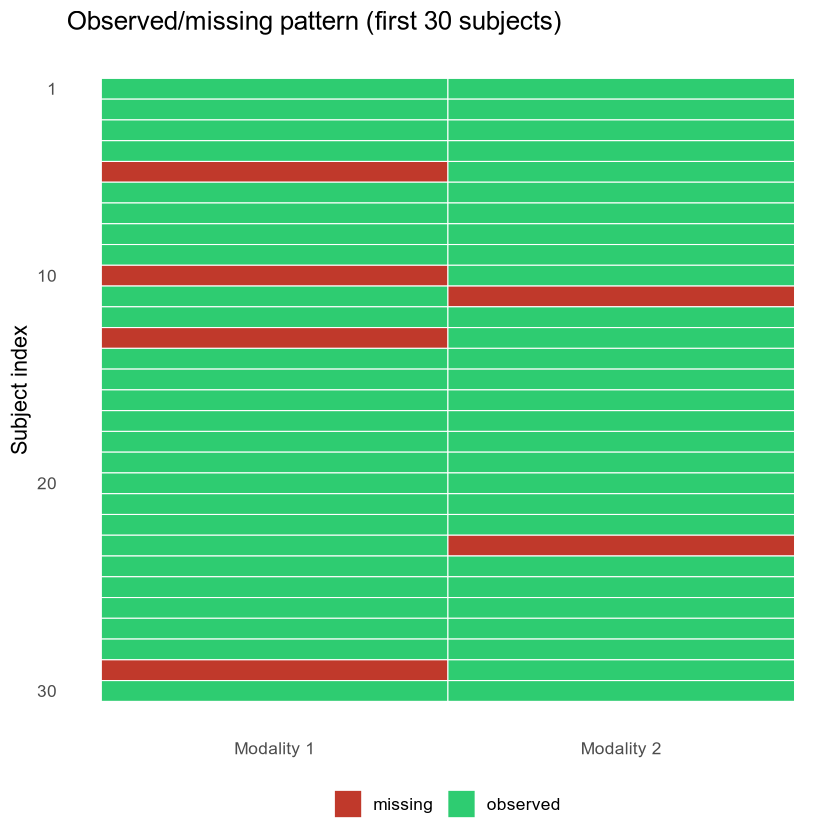

In [5]:

# ── Visual: missing-data pattern ─────────────────────────────────────────────
# Heatmap of observed (white) vs missing (dark) for the first 20 subjects
# across the two modalities.
library(ggplot2)

obs_df <- do.call(rbind, lapply(1:2, function(m) {
  Y_m <- if (m == 1) Y1 else Y2
  data.frame(
    subject  = seq_len(nrow(Y_m)),
    modality = paste0("Modality ", m),
    observed = as.integer(!is.na(Y_m[, 1]))
  )
}))
obs_df$modality <- factor(obs_df$modality)

ggplot(obs_df[obs_df$subject <= 30, ],
       aes(x = modality, y = subject, fill = factor(observed))) +
  geom_tile(colour = "white", linewidth = 0.3) +
  scale_fill_manual(values = c("0" = "#c0392b", "1" = "#2ecc71"),
                    labels = c("missing", "observed"),
                    name = NULL) +
  scale_y_reverse(breaks = c(1, 10, 20, 30)) +
  labs(title = "Observed/missing pattern (first 30 subjects)",
       x = NULL, y = "Subject index") +
  theme_minimal(base_size = 13) +
  theme(panel.grid = element_blank(),
        legend.position = "bottom")


### Inspect the `na_idx` field on the internal data object

`create_mf_individual` is the constructor called internally by `mfsusie`.
We can call it directly to inspect the resulting object without running the
full IBSS loop.

In [6]:
data_obj <- mfsusieR:::create_mf_individual(
  X   = X,
  Y   = list(Y1, Y2),
  pos = list(seq_len(T1), seq_len(T2))
)

# na_idx[[m]] = integer vector of observed row indices for modality m
cat("na_idx[[1]] length:", length(data_obj$na_idx[[1]]),
    "  (expected", sum(complete.cases(Y1)), ")\n")
cat("na_idx[[2]] length:", length(data_obj$na_idx[[2]]),
    "  (expected", sum(complete.cases(Y2)), ")\n")

# Verify: the missing rows are absent
cat("Any miss1 rows in na_idx[[1]]?",
    any(miss1 %in% data_obj$na_idx[[1]]), "\n")
cat("Any miss2 rows in na_idx[[2]]?",
    any(miss2 %in% data_obj$na_idx[[2]]), "\n")

# xtx_diag_list[[m]] uses X[na_idx[[m]], ] not X[1:n, ]
# -> the two vectors differ when observed subsets differ
cat("\nxtx_diag_list[[1]][1]:", data_obj$xtx_diag_list[[1]][1],
    "  vs  naive colSums(X^2)[1]:", sum(X[, 1]^2), "\n")
cat("xtx_diag_list[[1]][1]  (manual from na_idx):",
    sum(X[data_obj$na_idx[[1]], 1]^2), "\n")

na_idx[[1]] length: 65   (expected 65 )
na_idx[[2]] length: 70   (expected 70 )
Any miss1 rows in na_idx[[1]]? FALSE 
Any miss2 rows in na_idx[[2]]? FALSE 

xtx_diag_list[[1]][1]: 70.93935   vs  naive colSums(X^2)[1]: 86 
xtx_diag_list[[1]][1]  (manual from na_idx): 72 


### Run `mfsusie` on the ragged-observation data

In [7]:
fit <- mfsusie(
  X        = X,
  Y        = list(Y1, Y2),
  pos      = list(seq_len(T1), seq_len(T2)),
  L        = L,
  max_iter = 20L,
  verbose  = FALSE
)

cat("Converged:", fit$converged, " | niter:", fit$niter, "\n")

Converged: TRUE  | niter: 2 


### Verify recovery of the true signal

In [8]:
cat("PIP at true variant 10:", round(fit$pip[10], 3), "\n")
cat("Top-5 PIPs:\n")
top5 <- order(fit$pip, decreasing = TRUE)[1:5]
print(data.frame(variant = top5, pip = round(fit$pip[top5], 3)))

cs <- fit$sets$cs
cat("\nNumber of credible sets:", length(cs), "\n")
if (length(cs) > 0L) {
  for (k in seq_along(cs)) {
    cat(sprintf("  CS %d: variants %s\n", k, paste(cs[[k]], collapse = ", ")))
  }
}

PIP at true variant 10: 1 
Top-5 PIPs:
  variant pip
1      10   1
2       1   0
3       2   0
4       3   0
5       4   0

Number of credible sets: 1 
  CS 1: variants 10


### Compare: what happens if we naively zero-fill instead of using na_idx?

Setting missing rows to zero would include them as pseudo-observations with
zero response, which inflates $n_m$ and biases $\hat\sigma^2_m$ downward.

In [9]:
Y1_zerofill <- Y1; Y1_zerofill[is.na(Y1_zerofill)] <- 0
Y2_zerofill <- Y2; Y2_zerofill[is.na(Y2_zerofill)] <- 0

fit_zero <- mfsusie(
  X        = X,
  Y        = list(Y1_zerofill, Y2_zerofill),
  pos      = list(seq_len(T1), seq_len(T2)),
  L        = L,
  max_iter = 20L,
  verbose  = FALSE
)

cat("Zero-fill sigma2[[1]]:", round(unlist(fit_zero$sigma2[[1]]), 4), "\n")
cat("NA-aware  sigma2[[1]]:", round(unlist(fit$sigma2[[1]]),      4), "\n\n")
cat("Zero-fill PIP at variant 10:", round(fit_zero$pip[10], 3), "\n")
cat("NA-aware  PIP at variant 10:", round(fit$pip[10],      3), "\n")

Zero-fill sigma2[[1]]: 0.9655 
NA-aware  sigma2[[1]]: 0.9545 

Zero-fill PIP at variant 10: 1 
NA-aware  PIP at variant 10: 1 


### Visual: PIP comparison

Each segment connects the NA-aware PIP (circle) to the zero-fill PIP (triangle) for the same variant.  The dashed line marks the true causal variant (10).

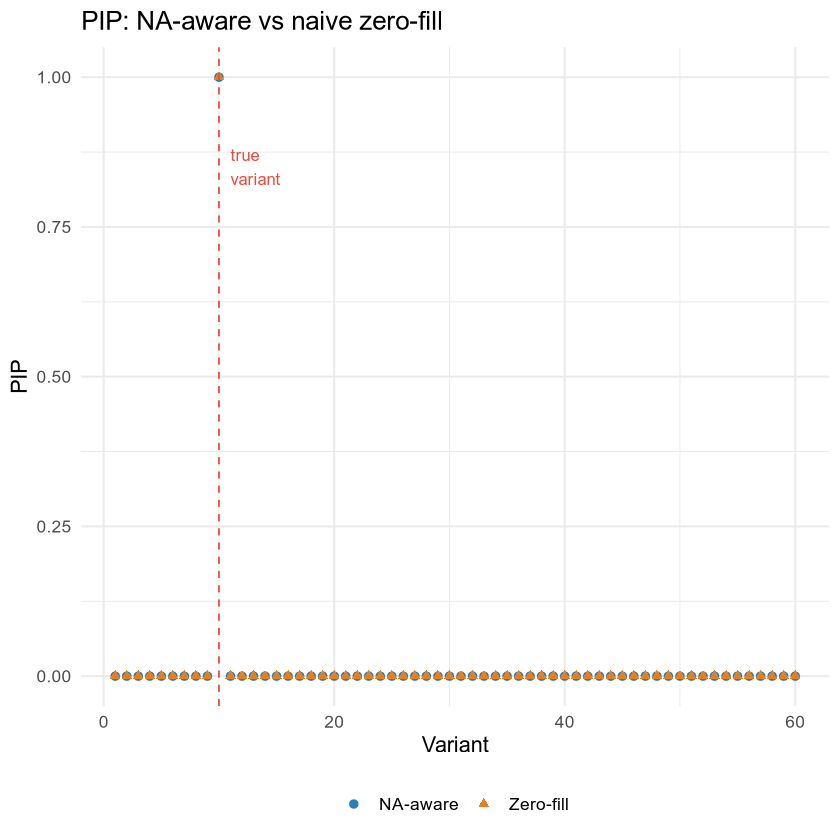

In [10]:

# ── Visual: PIP comparison — NA-aware vs zero-fill ───────────────────────────
pip_df <- data.frame(
  variant  = seq_len(p),
  na_aware = fit$pip,
  zerofill = fit_zero$pip,
  is_true  = seq_len(p) == 10L
)

ggplot(pip_df, aes(x = variant)) +
  geom_segment(aes(xend = variant, y = na_aware, yend = zerofill),
               colour = "grey70", linewidth = 0.4) +
  geom_point(aes(y = na_aware,  colour = "NA-aware"),  size = 2) +
  geom_point(aes(y = zerofill, colour = "Zero-fill"), size = 2, shape = 17) +
  geom_vline(xintercept = 10, linetype = "dashed", colour = "#e74c3c") +
  annotate("text", x = 11, y = 0.85, label = "true\nvariant",
           colour = "#e74c3c", size = 3.5, hjust = 0) +
  scale_colour_manual(values = c("NA-aware" = "#2980b9",
                                  "Zero-fill" = "#e67e22"),
                      name = NULL) +
  labs(title = "PIP: NA-aware vs naive zero-fill",
       x = "Variant", y = "PIP") +
  ylim(0, 1) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")


The zero-fill path underestimates $\sigma^2$ because the zero rows reduce the
RSS artificially.  This shifts the prior towards larger effects and generally
inflates PIPs for non-causal variants.

---

## Summary

| Field | Created at | Shape | Used for |
|---|---|---|---|
| `data$na_idx[[m]]` | `create_mf_individual`, line 167 | integer vector, length $n_m$ | row index into $X$ and $R_m$ at every IBSS step |
| `data$xtx_diag_list[[m]]` | `create_mf_individual`, line 168-169 | length-$p$ numeric | $\hat{B}_m$ and $\hat{S}^2_m$ denominator; bias-correction term in $\widehat{\text{ER}^2}$ |

Every aggregation over samples inside the IBSS loop (residuals, likelihood,
variance estimates) restricts to `na_idx[[m]]` for modality $m$.  There is
no single $n$: each modality contributes through its own $n_m = |\mathcal{I}_m|$.

This matches the `ind_analysis` design in `mvf.susie.alpha`, with the only
difference being the field name.